# Módulo 12 · VAR y predicción integradora

Curso: **Series Temporales con R y Python** (Frogames Formación).

Código de acompañamiento de la lección `12-prediciendo-el-futuro/01-var-y-prediccion-integradora`. Es el repaso integrador del módulo: en vez de un dataset de juguete, se trabaja con tres índices bursátiles descargados en vivo (S&P 500, FTSE 100, DAX), se calculan sus retornos diarios (el mismo tipo de transformación que en el Módulo 1), y se ajusta un modelo **VAR (Vector Autoregression)** — el primer modelo del curso que predice varias series a la vez, capturando cómo se influyen mutuamente.

In [1]:
# Opcional: así se descargaron los datos. No hace falta ejecutar esta celda
# para seguir el resto del notebook (el CSV ya está en esta carpeta).

import yfinance as yf

tickers = ["^GSPC", "^FTSE", "^GDAXI"]
data_live = yf.download(tickers, start="2015-01-01", end="2026-09-16",
                         interval="1d", threads=False)["Close"]
data_live = data_live.dropna()
data_live.columns = ["sp500", "ftse", "dax"]
data_live.index.name = "date"
data_live.to_csv("yahoo_indices_2015_2026.csv")
data_live.tail()

[                       0%                       ]

[**********************67%*******                ]  2 of 3 completed

[*********************100%***********************]  3 of 3 completed

[*********************100%***********************]  3 of 3 completed

,sp500,ftse,dax
date,,,
2026-09-09,10670.099609,25576.449219,7636.359863
2026-09-10,10608.900391,25361.150391,7591.700195
2026-09-11,10650.400391,25568.560547,7656.979980
2026-09-14,10697.599609,25440.810547,7619.979980
2026-09-15,10658.099609,25402.279297,7585.729980


## Carga y retornos

Tres índices, tres mercados (EE. UU., Reino Unido, Alemania), alineados por día de solapamiento real de las tres bolsas (`dropna()` tras el `join` implícito de `yfinance` descarta los días en que alguna de las tres no cotizó).

In [2]:
import pandas as pd

df = pd.read_csv("yahoo_indices_2015_2026.csv", parse_dates=["date"], index_col="date")
print(df.shape)
df.tail()

(2857, 3)


,sp500,ftse,dax
date,,,
2026-09-09,10670.099609,25576.449219,7636.359863
2026-09-10,10608.900391,25361.150391,7591.700195
2026-09-11,10650.400391,25568.560547,7656.979980
2026-09-14,10697.599609,25440.810547,7619.979980
2026-09-15,10658.099609,25402.279297,7585.729980


In [3]:
returns = df.pct_change().dropna() * 100  # retornos diarios en %
returns.describe()

,sp500,ftse,dax
count,2856.000000,2856.000000,2856.000000
mean,0.021844,0.040892,0.051988
std,0.975841,1.215609,1.121132
min,-10.873819,-12.238615,-11.984055
25%,-0.424055,-0.508784,-0.384633
50%,0.064880,0.075733,0.070255
75%,0.507680,0.665088,0.581261
max,9.053047,10.975900,9.515388


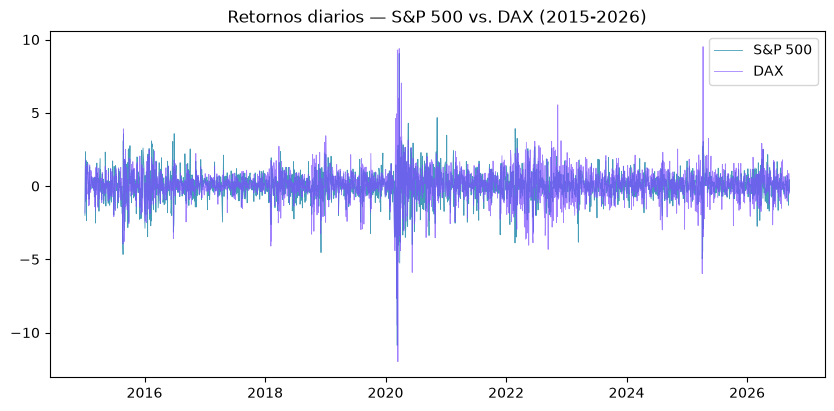

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(returns.index, returns["sp500"], color="#449cb9", linewidth=0.6, label="S&P 500")
ax.plot(returns.index, returns["dax"], color="#7c4dff", linewidth=0.6, alpha=0.7, label="DAX")
ax.legend()
ax.set_title("Retornos diarios — S&P 500 vs. DAX (2015-2026)")
plt.savefig("var_retornos.png", dpi=110, bbox_inches="tight")
plt.show()

## Selección del orden del VAR

`VAR.select_order` prueba varios números de *lags* y elige el mejor según criterios de información (AIC, BIC, HQIC, FPE). No se fija el orden a ojo: se deja que el propio criterio lo decida, igual que se hará con Auto ARIMA más adelante en el módulo.

In [5]:
from statsmodels.tsa.api import VAR

model = VAR(returns)
order_sel = model.select_order(maxlags=10)
print(order_sel.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -0.8698     -0.8635      0.4190     -0.8676
1      -0.9900    -0.9649*      0.3716     -0.9809
2      -0.9969     -0.9530      0.3690    -0.9811*
3      -0.9948     -0.9320      0.3698     -0.9721
4      -0.9994     -0.9178      0.3681     -0.9699
5      -0.9972     -0.8968      0.3689     -0.9610
6       -1.012     -0.8924      0.3636     -0.9686
7       -1.014     -0.8763      0.3626     -0.9645
8       -1.019     -0.8616      0.3611     -0.9619
9      -1.025*     -0.8497     0.3586*     -0.9620
10      -1.021     -0.8267      0.3601     -0.9511
--------------------------------------------------


/tmp/m12venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


## Ajuste del VAR y predicción

Se ajusta con el orden que sugiere AIC y se predicen los próximos 5 días para las tres series simultáneamente — la diferencia clave frente a todos los modelos univariantes vistos hasta ahora (AR, MA, ARMA, ARIMA, ARCH): un único modelo predice `sp500`, `ftse` y `dax` a la vez, usando la información cruzada entre las tres.

In [6]:
p = order_sel.aic
results = model.fit(p)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 16, Sep, 2026
Time:                     19:00:33
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                  -0.849893
Nobs:                     2847.00    HQIC:                 -0.962208
Log likelihood:          -10575.3    FPE:                   0.358594
AIC:                     -1.02556    Det(Omega_mle):        0.348219
--------------------------------------------------------------------
Results for equation sp500
              coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------
const            0.017144         0.017934            0.956           0.339
L1.sp500        -0.065241         0.031414           -2.077           0.038
L1.ftse         -0.052989         0.026173           -2.025           0.043
L1.d

In [7]:
forecast = results.forecast(returns.values[-p:], steps=5)
forecast_df = pd.DataFrame(forecast, columns=returns.columns,
                            index=pd.bdate_range(returns.index[-1], periods=6)[1:])
forecast_df

,sp500,ftse,dax
2026-09-16,-0.105348,-0.124704,0.024620
2026-09-17,0.055390,0.069616,0.128223
2026-09-18,0.045576,0.097626,0.014703
2026-09-21,-0.036959,-0.034005,-0.022303
2026-09-22,0.167913,0.161710,0.171663


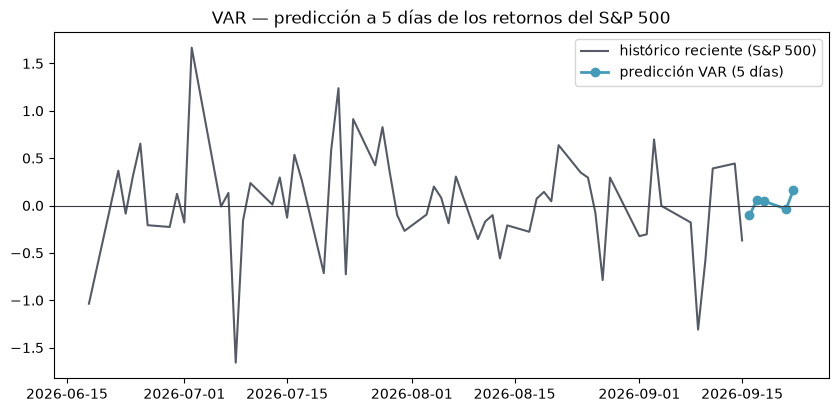

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(returns.index[-60:], returns["sp500"].iloc[-60:], color="#555b66", label="histórico reciente (S&P 500)")
ax.plot(forecast_df.index, forecast_df["sp500"], color="#449cb9", marker="o", linewidth=2, label="predicción VAR (5 días)")
ax.axhline(0, color="#3a3a42", linewidth=0.8)
ax.legend()
ax.set_title("VAR — predicción a 5 días de los retornos del S&P 500")
plt.savefig("var_forecast_sp500.png", dpi=110, bbox_inches="tight")
plt.show()

## Causalidad de Granger: ¿ayuda el DAX a predecir el S&P 500?

El test de causalidad de Granger no prueba causalidad real, sino si los valores pasados de una serie mejoran la predicción de otra por encima de usar solo el pasado de la propia serie — la pregunta natural una vez se tiene un VAR ajustado.

In [9]:
gc = results.test_causality(caused="sp500", causing=["dax", "ftse"], kind="f")
print(gc.summary())

Granger causality F-test. H_0: ['dax', 'ftse'] do not Granger-cause sp500. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value          df         
----------------------------------------------------------
         10.09          1.605   0.000 (18, np.int64(8457))
----------------------------------------------------------


## Cierre del repaso integrador

Este notebook cierra el hilo de modelos univariantes del curso (AR → MA → ARMA → ARIMA → ARCH → GARCH → Auto ARIMA) añadiendo la pieza multivariante: un VAR que predice varios mercados a la vez y permite preguntar si uno "ayuda" a predecir a otro (test de Granger). El resto del Módulo 12 explora técnicas complementarias: Prophet, Bitcoin y detección de atípicos, inversión de la diferenciación, y una comparación final Auto ARIMA vs. Prophet.